## Exploratory Data Analysis

This notebook explores the raw `flights_with_weather.csv` dataset. We start by loading all 32 columns to inspect data quality, missing values, and leakage structure. Then we narrow to the relevant features for the visualization-heavy sections.

| Section | Content |
|---|---|
| 1.0 | Data Loading & Initial Inspection |
| 1.1 | Data Quality & Missing Values |
| 1.2 | Leakage Identification & Feature Classification |
| 1.3 | Class Imbalance |
| 1.4 | Temporal Patterns |
| 1.5 | Airline Analysis |
| 1.6 | Airport & Route Analysis |
| 1.7 | Weather Data Analysis |
| 1.8 | Cancellation Code Analysis |
| 1.9 | Correlation Heatmap |

In [47]:
import os, gc, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

RAW_DATA_PATH = 'flights_with_weather.csv'


---
### 1.0 Data Loading & Initial Inspection

We start by loading the **full** dataset (all 32 columns) so we can inspect every field, check missing values, and identify leakage. After the data-quality checks, we'll narrow down to the columns we actually need for the rest of the EDA.

In [48]:
if not os.path.exists(RAW_DATA_PATH):
    print('CSV not found locally — downloading from Kaggle...')
    import kagglehub, glob
    path = kagglehub.dataset_download(
        'huskydawg/flight-cancellation2019-2023-full-with-weather')
    RAW_DATA_PATH = glob.glob(f'{path}/**/*.csv', recursive=True)[0]
    print(f'Downloaded: {RAW_DATA_PATH}')

dtype_hints = {
    'AIRLINE': 'category', 'AIRLINE_DOT': 'category',
    'AIRLINE_CODE': 'category',
    'ORIGIN': 'category', 'ORIGIN_CITY': 'category',
    'DEST': 'category', 'DEST_CITY': 'category',
    'CANCELLED': 'float32', 'DIVERTED': 'float32',
    'CRS_DEP_TIME': 'int32', 'CRS_ARR_TIME': 'int32',
    'DISTANCE': 'float32', 'CRS_ELAPSED_TIME': 'float32',
}

df_full = pd.read_csv(RAW_DATA_PATH, dtype=dtype_hints, parse_dates=['FL_DATE'])
df_full['CANCELLED'] = df_full['CANCELLED'].fillna(0).astype('int8')

print(f'Full dataset: {df_full.shape[0]:,} rows x {df_full.shape[1]} columns')
print(f'Date range:   {df_full.FL_DATE.min().date()} to {df_full.FL_DATE.max().date()}')
print(f'Cancel rate:  {df_full.CANCELLED.mean():.2%}')
print(f'Memory usage: {df_full.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Full dataset: 3,234,981 rows x 44 columns
Date range:   2019-01-01 to 2023-12-31
Cancel rate:  2.65%
Memory usage: 985.1 MB


### 1.1 Data Quality & Missing Values

Let's look at how many values are missing in each column, and whether it follows a pattern.

In [49]:
missing = pd.DataFrame({
    'Missing Count': df_full.isnull().sum(),
    'Missing %': (df_full.isnull().sum() / len(df_full) * 100).round(2),
    'Dtype': df_full.dtypes,
}).sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {(missing["Missing Count"] > 0).sum()} / {len(missing)}')
display(missing[missing['Missing Count'] > 0])

Columns with missing values: 17 / 44


,Missing Count,Missing %,Dtype
CANCELLATION_CODE,3149230,97.35,object
DELAY_DUE_CARRIER,2665058,82.38,float64
DELAY_DUE_NAS,2665058,82.38,float64
DELAY_DUE_SECURITY,2665058,82.38,float64
DELAY_DUE_LATE_AIRCRAFT,2665058,82.38,float64
DELAY_DUE_WEATHER,2665058,82.38,float64
AIR_TIME,93203,2.88,float64
ELAPSED_TIME,93203,2.88,float64
ARR_DELAY,93203,2.88,float64
ARR_TIME,86598,2.68,float64


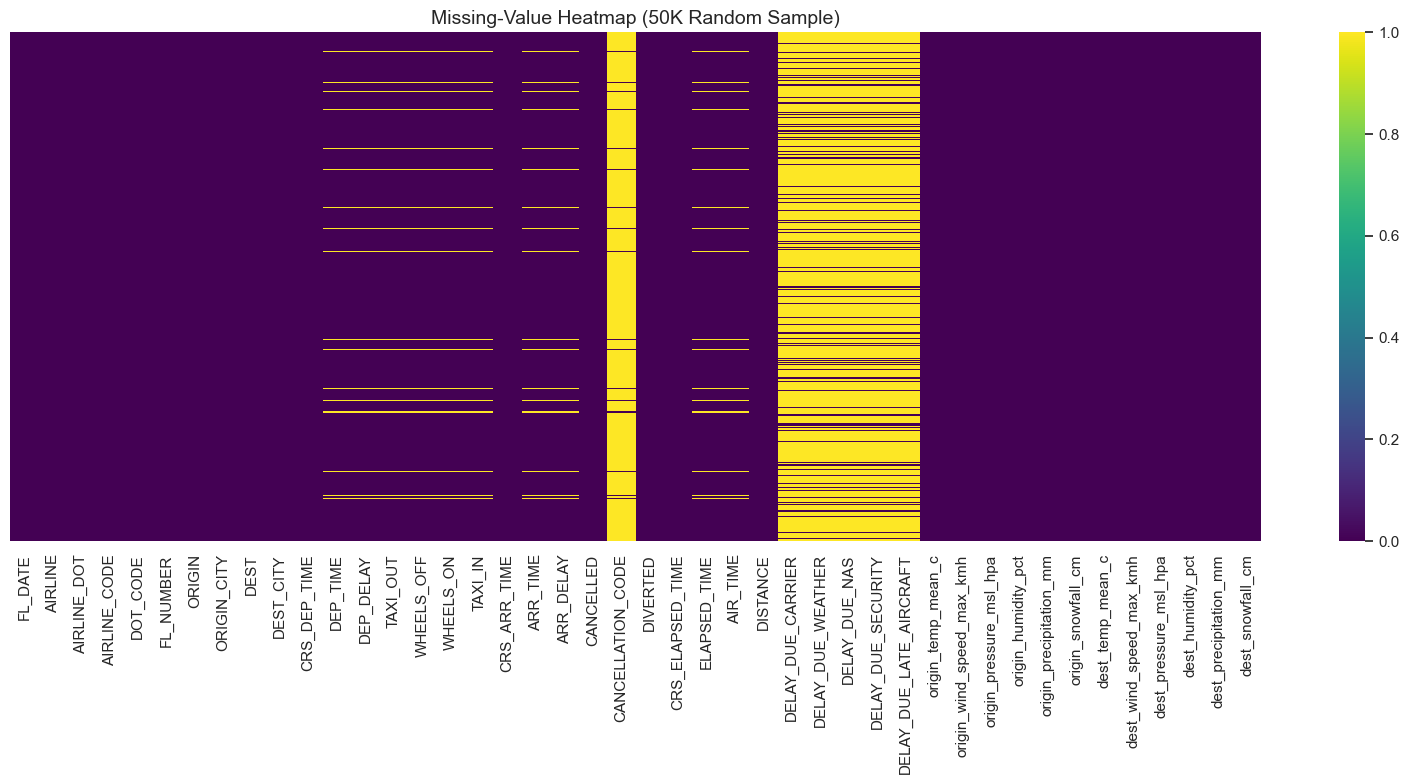

In [50]:
sample = df_full.sample(n=min(50_000, len(df_full)), random_state=42)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(sample.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing-Value Heatmap (50K Random Sample)', fontsize=14)
plt.tight_layout()
plt.show()

### 1.2 Leakage Identification & Feature Classification

If we compare missing data for cancelled vs operated flights, we can see that certain post-departure columns (actual times, delays, etc.) are *always* missing when a flight is cancelled. This is target leakage — those columns reveal the answer we're trying to predict.

In [51]:
cancelled_df = df_full[df_full['CANCELLED'] == 1]
operated_df  = df_full[df_full['CANCELLED'] == 0]

compare = pd.DataFrame({
    'Missing % (Cancelled)': (cancelled_df.isnull().mean() * 100).round(2),
    'Missing % (Operated)':  (operated_df.isnull().mean() * 100).round(2),
}).sort_values('Missing % (Cancelled)', ascending=False)

print('Columns that are systematically missing only for cancelled flights:')
display(compare[compare['Missing % (Cancelled)'] > 90])

del cancelled_df, operated_df, sample

Columns that are systematically missing only for cancelled flights:


,Missing % (Cancelled),Missing % (Operated)
DELAY_DUE_CARRIER,100.00,81.90
DELAY_DUE_NAS,100.00,81.90
AIR_TIME,100.00,0.24
ELAPSED_TIME,100.00,0.24
DELAY_DUE_SECURITY,100.00,81.90
DELAY_DUE_LATE_AIRCRAFT,100.00,81.90
ARR_DELAY,100.00,0.24
ARR_TIME,100.00,0.03
TAXI_IN,100.00,0.03
WHEELS_ON,100.00,0.03


Based on this, here's how we classify the columns:

| Category | Columns | Why |
|----------|---------|-----|
| **Target** | `CANCELLED` | What we're predicting |
| **Pre-departure (safe to use)** | `FL_DATE`, `AIRLINE_CODE`, `ORIGIN`, `DEST`, `CRS_DEP_TIME`, `CRS_ARR_TIME`, `CRS_ELAPSED_TIME`, `DISTANCE` | Known before the flight departs |
| **Post-departure (leakage — drop)** | `DEP_TIME`, `DEP_DELAY`, `TAXI_OUT`, `WHEELS_OFF`, `WHEELS_ON`, `TAXI_IN`, `ARR_TIME`, `ARR_DELAY`, `ELAPSED_TIME`, `AIR_TIME`, `DELAY_DUE_*` (5), `DIVERTED`, `CANCELLATION_CODE` | Only known after departure or cancellation |
| **Redundant identifiers (drop)** | `AIRLINE`, `AIRLINE_DOT`, `DOT_CODE`, `FL_NUMBER`, `ORIGIN_CITY`, `DEST_CITY` | Duplicate encodings or unique IDs |
| **Weather (if merged)** | `origin_temp_mean_c`, `origin_wind_speed_max_kmh`, etc. | Observable before departure |

Now that we've inspected all 32 columns, we can narrow down to just the ones we need for the rest of the EDA.

In [52]:
eda_cols = [
    'FL_DATE', 'AIRLINE_CODE', 'ORIGIN', 'DEST',
    'CRS_DEP_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE',
    'CANCELLED', 'CANCELLATION_CODE',
]

weather_cols = [c for c in df_full.columns if c.startswith('origin_') or c.startswith('dest_')]
eda_cols = eda_cols + weather_cols

df_raw = df_full[eda_cols].copy()

df_raw['YEAR']        = df_raw['FL_DATE'].dt.year
df_raw['MONTH']       = df_raw['FL_DATE'].dt.month
df_raw['DAY_OF_WEEK'] = df_raw['FL_DATE'].dt.dayofweek
df_raw['DEP_HOUR']    = (df_raw['CRS_DEP_TIME'] // 100).clip(0, 23)

del df_full
gc.collect()

print(f'Narrowed to {len(df_raw):,} rows x {df_raw.shape[1]} cols for the rest of the EDA')
if weather_cols:
    print(f'Weather columns included: {weather_cols}')
else:
    print('No weather columns found in this dataset.')

Narrowed to 3,234,981 rows x 25 cols for the rest of the EDA
Weather columns included: ['origin_temp_mean_c', 'origin_wind_speed_max_kmh', 'origin_pressure_msl_hpa', 'origin_humidity_pct', 'origin_precipitation_mm', 'origin_snowfall_cm', 'dest_temp_mean_c', 'dest_wind_speed_max_kmh', 'dest_pressure_msl_hpa', 'dest_humidity_pct', 'dest_precipitation_mm', 'dest_snowfall_cm']


### 1.3 Class Imbalance

Only about 2.6% of flights are cancelled — so a naive model that always predicts "not cancelled" would get 97.4% accuracy. That's why we focus on **PR-AUC** instead of accuracy as our primary evaluation metric.

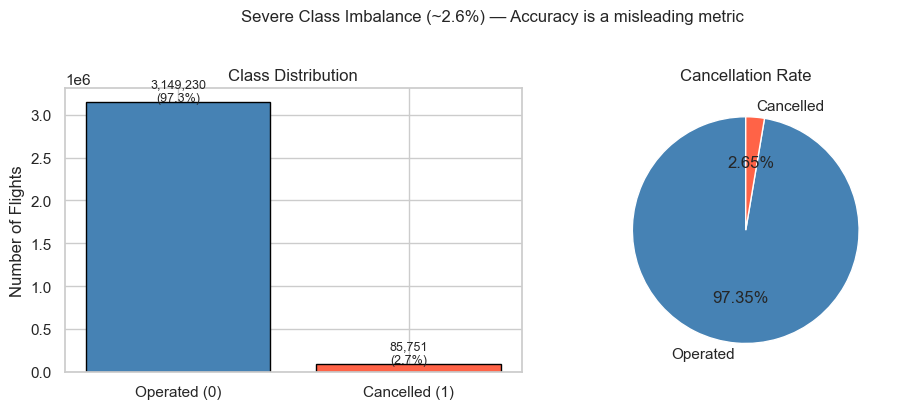

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df_raw['CANCELLED'].value_counts().sort_index()
labels = ['Operated (0)', 'Cancelled (1)']
colors = ['steelblue', 'tomato']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Flights')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15000, f'{v:,}\n({v/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=9)

axes[1].pie(counts.values, labels=['Operated', 'Cancelled'],
            colors=colors, autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Cancellation Rate')

plt.suptitle('Severe Class Imbalance (~2.6%) — Accuracy is a misleading metric',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 1.4 Temporal Patterns

Looking at cancellation rates across years, months, days, and hours of the day. The huge 2020 spike is why we decided to run an ablation study — training models both with and without an `IS_COVID` flag to see if it actually helps.

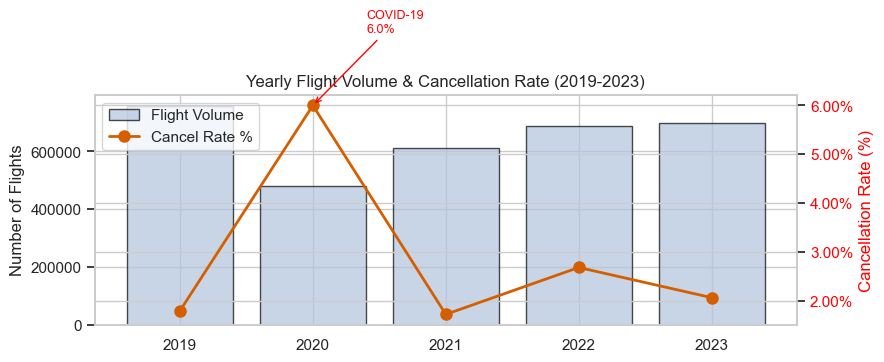

In [54]:
yearly = (
    df_raw.groupby('YEAR')['CANCELLED']
    .agg(Cancel_Rate='mean', Total_Flights='count')
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

ax1.bar(yearly['YEAR'], yearly['Total_Flights'],
        color='lightsteelblue', edgecolor='black', alpha=0.7, label='Flight Volume')
ax2.plot(yearly['YEAR'], yearly['Cancel_Rate'] * 100,
         'ro-', linewidth=2, markersize=8, label='Cancel Rate %')

covid_rate = yearly.loc[yearly['YEAR'] == 2020, 'Cancel_Rate'].iloc[0]
ax2.annotate(
    f'COVID-19\n{covid_rate:.1%}',
    xy=(2020, covid_rate * 100),
    xytext=(2020.4, covid_rate * 100 + 1.5),
    arrowprops=dict(arrowstyle='->', color='red'),
    color='red', fontsize=9
)

ax1.set_ylabel('Number of Flights')
ax2.set_ylabel('Cancellation Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc='upper left')
ax1.set_title('Yearly Flight Volume & Cancellation Rate (2019-2023)')
plt.tight_layout()
plt.show()

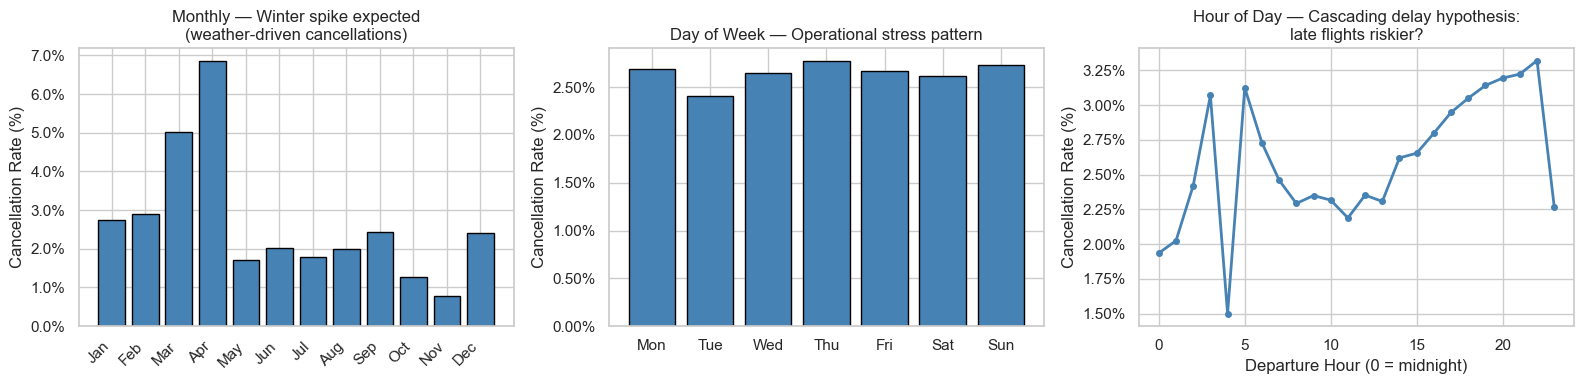

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Monthly
monthly = df_raw.groupby('MONTH')['CANCELLED'].mean() * 100
axes[0].bar(monthly.index, monthly.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45, ha='right')
axes[0].set_ylabel('Cancellation Rate (%)')
axes[0].set_title('Monthly — Winter spike expected\n(weather-driven cancellations)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# Day of week
dow = df_raw.groupby('DAY_OF_WEEK')['CANCELLED'].mean() * 100
axes[1].bar(dow.index, dow.values, color='steelblue', edgecolor='black')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_title('Day of Week — Operational stress pattern')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# Hour of day
hourly = df_raw.groupby('DEP_HOUR')['CANCELLED'].mean() * 100
axes[2].plot(hourly.index, hourly.values, 'o-',
             color='steelblue', linewidth=2, markersize=4)
axes[2].set_xlabel('Departure Hour (0 = midnight)')
axes[2].set_ylabel('Cancellation Rate (%)')
axes[2].set_title('Hour of Day — Cascading delay hypothesis:\nlate flights riskier?')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

### 1.5 Airline Analysis

There's a wide spread in cancellation rates across airlines — some carriers cancel 2-3x more often than others. This makes `AIRLINE_CODE` a strong predictor. In the preprocessing pipeline, we use target encoding to turn each airline code into its historical cancellation rate.

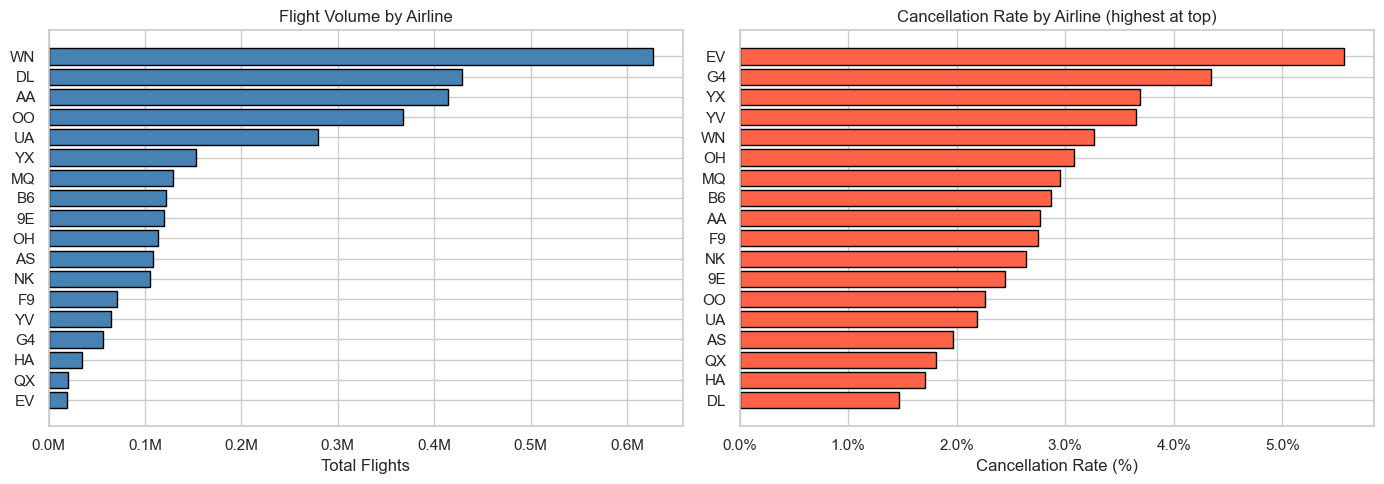

Top 5 Most Reliable Airlines:
AIRLINE_CODE  Flights  Cancel_Pct
          UA   279535    2.184700
          AS   108637    1.969863
          QX    20634    1.812542
          HA    35011    1.708035
          DL   428501    1.463941

Top 5 Most Cancellation-Prone Airlines:
AIRLINE_CODE  Flights  Cancel_Pct
          EV    19082    5.565454
          G4    56282    4.342419
          YX   153104    3.685730
          YV    65012    3.650095
          WN   626740    3.268820


In [56]:
airline_stats = (
    df_raw.groupby('AIRLINE_CODE')['CANCELLED']
    .agg(Flights='count', Cancel_Rate='mean')
    .assign(Cancel_Pct=lambda x: x['Cancel_Rate'] * 100)
    .sort_values('Cancel_Rate', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vol = airline_stats.sort_values('Flights', ascending=True)
axes[0].barh(vol['AIRLINE_CODE'], vol['Flights'],
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('Total Flights')
axes[0].set_title('Flight Volume by Airline')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

axes[1].barh(airline_stats['AIRLINE_CODE'][::-1],
             airline_stats['Cancel_Pct'][::-1],
             color='tomato', edgecolor='black')
axes[1].set_xlabel('Cancellation Rate (%)')
axes[1].set_title('Cancellation Rate by Airline (highest at top)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print('Top 5 Most Reliable Airlines:')
print(airline_stats.tail(5)[['AIRLINE_CODE','Flights','Cancel_Pct']].to_string(index=False))
print('\nTop 5 Most Cancellation-Prone Airlines:')
print(airline_stats.head(5)[['AIRLINE_CODE','Flights','Cancel_Pct']].to_string(index=False))

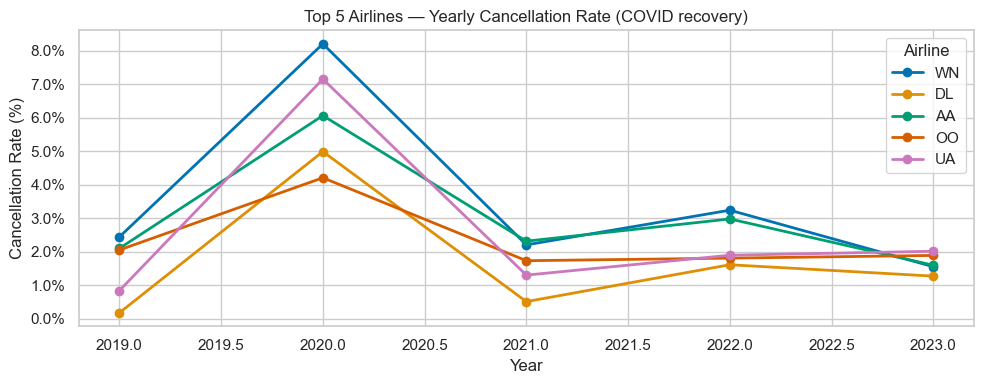

In [57]:
top5 = airline_stats.sort_values('Flights', ascending=False).head(5)['AIRLINE_CODE'].tolist()

airline_yearly = (
    df_raw[df_raw['AIRLINE_CODE'].isin(top5)]
    .groupby(['YEAR', 'AIRLINE_CODE'])['CANCELLED']
    .mean().mul(100).reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for airline in top5:
    d = airline_yearly[airline_yearly['AIRLINE_CODE'] == airline]
    ax.plot(d['YEAR'], d['CANCELLED'], marker='o', label=airline, linewidth=2)

ax.set_xlabel('Year')
ax.set_ylabel('Cancellation Rate (%)')
ax.set_title('Top 5 Airlines — Yearly Cancellation Rate (COVID recovery)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Airline')
plt.tight_layout()
plt.show()

### 1.6 Airport & Route Analysis

Certain airports are inherently riskier due to geography and weather (e.g., SFO fog, ORD snow). We use target encoding on `ORIGIN` and `DEST` so the model can pick up on these patterns.

We also want to check whether short-haul flights get cancelled more often than longer routes.

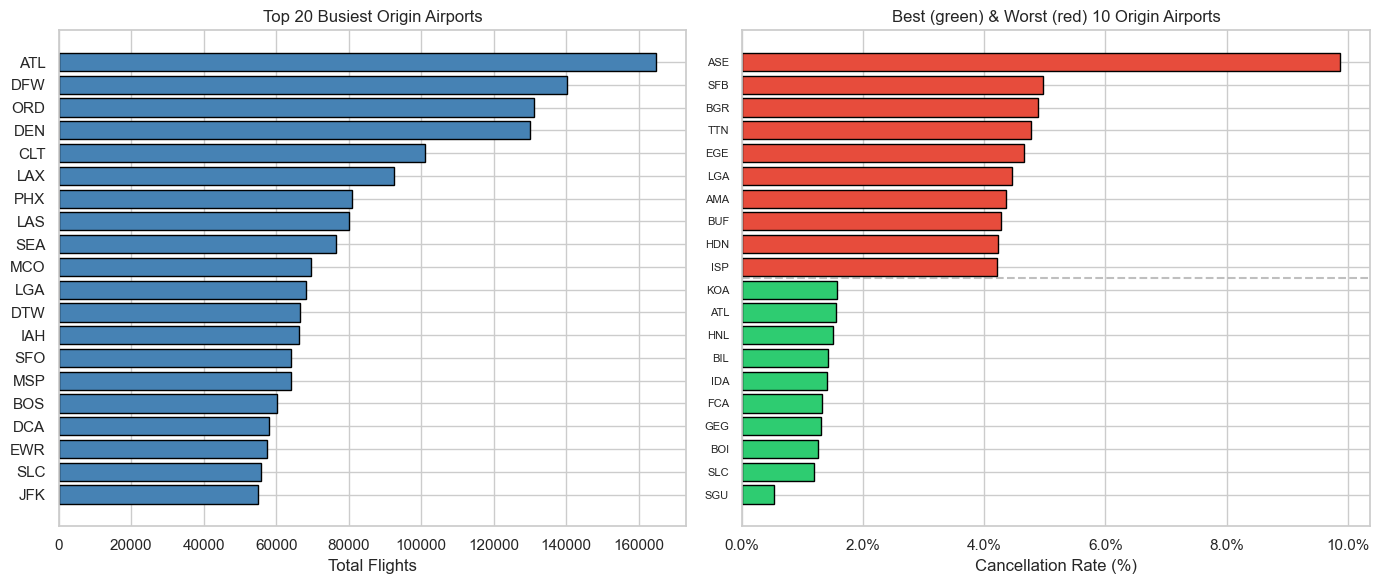

In [58]:
top20 = df_raw['ORIGIN'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top20.index[::-1], top20.values[::-1],
             color='steelblue', edgecolor='black')
axes[0].set_xlabel('Total Flights')
axes[0].set_title('Top 20 Busiest Origin Airports')

airport_cancel = (
    df_raw.groupby('ORIGIN')['CANCELLED']
    .agg(Flights='count', Cancel_Rate='mean')
    .query('Flights >= 1000')
    .sort_values('Cancel_Rate')
)
airport_cancel['Cancel_Pct'] = airport_cancel['Cancel_Rate'] * 100
top_bottom = pd.concat([airport_cancel.head(10), airport_cancel.tail(10)])
colors = ['#2ecc71'] * 10 + ['#e74c3c'] * 10

axes[1].barh(range(len(top_bottom)), top_bottom['Cancel_Pct'],
             color=colors, edgecolor='black')
axes[1].set_yticks(range(len(top_bottom)))
axes[1].set_yticklabels(top_bottom.index, fontsize=8)
axes[1].set_xlabel('Cancellation Rate (%)')
axes[1].set_title('Best (green) & Worst (red) 10 Origin Airports')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].axhline(9.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

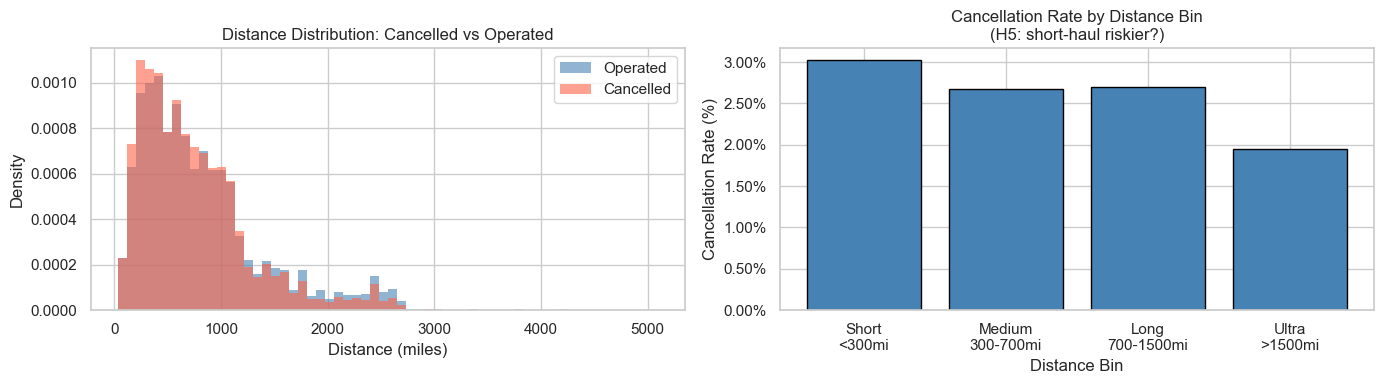

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distance distribution: cancelled vs operated
for label, color, lname in [(0, 'steelblue', 'Operated'), (1, 'tomato', 'Cancelled')]:
    pool = df_raw[df_raw.CANCELLED == label]['DISTANCE'].dropna()
    sample = pool.sample(min(50000, len(pool)), random_state=42)
    axes[0].hist(sample, bins=60, alpha=0.6, color=color,
                 label=lname, density=True, edgecolor='none')
axes[0].set_xlabel('Distance (miles)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distance Distribution: Cancelled vs Operated')
axes[0].legend()

# Binned distance vs cancellation rate
df_raw['DIST_BIN'] = pd.cut(
    df_raw['DISTANCE'],
    bins=[0, 300, 700, 1500, 5000],
    labels=['Short\n<300mi', 'Medium\n300-700mi', 'Long\n700-1500mi', 'Ultra\n>1500mi']
)
dist_cancel = df_raw.groupby('DIST_BIN')['CANCELLED'].mean() * 100
axes[1].bar(dist_cancel.index, dist_cancel.values,
            color='steelblue', edgecolor='black')
axes[1].set_xlabel('Distance Bin')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_title('Cancellation Rate by Distance Bin\n(H5: short-haul riskier?)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

### 1.7 Weather Data Analysis

Since weather is one of the top reasons flights get cancelled (Code B), let's take a closer look at the weather features in the dataset. We have 6 weather metrics for each of origin and destination airports: temperature, wind speed, pressure, humidity, precipitation, and snowfall.

In [60]:
wx_cols = [c for c in df_raw.columns if c.startswith('origin_') or c.startswith('dest_')]

if wx_cols:
    wx_missing = df_raw[wx_cols].isnull().mean().mul(100).round(1).sort_values(ascending=False)
    print('Weather column coverage (% missing):')
    display(wx_missing.to_frame('Missing %'))
else:
    print('No weather columns found — skipping weather EDA.')

Weather column coverage (% missing):


,Missing %
origin_temp_mean_c,0.0
origin_wind_speed_max_kmh,0.0
origin_pressure_msl_hpa,0.0
origin_humidity_pct,0.0
origin_precipitation_mm,0.0
origin_snowfall_cm,0.0
dest_temp_mean_c,0.0
dest_wind_speed_max_kmh,0.0
dest_pressure_msl_hpa,0.0
dest_humidity_pct,0.0


#### Weather feature distributions

Let's see what the weather data actually looks like - distributions of the key metrics, split by whether the flight was cancelled or not.

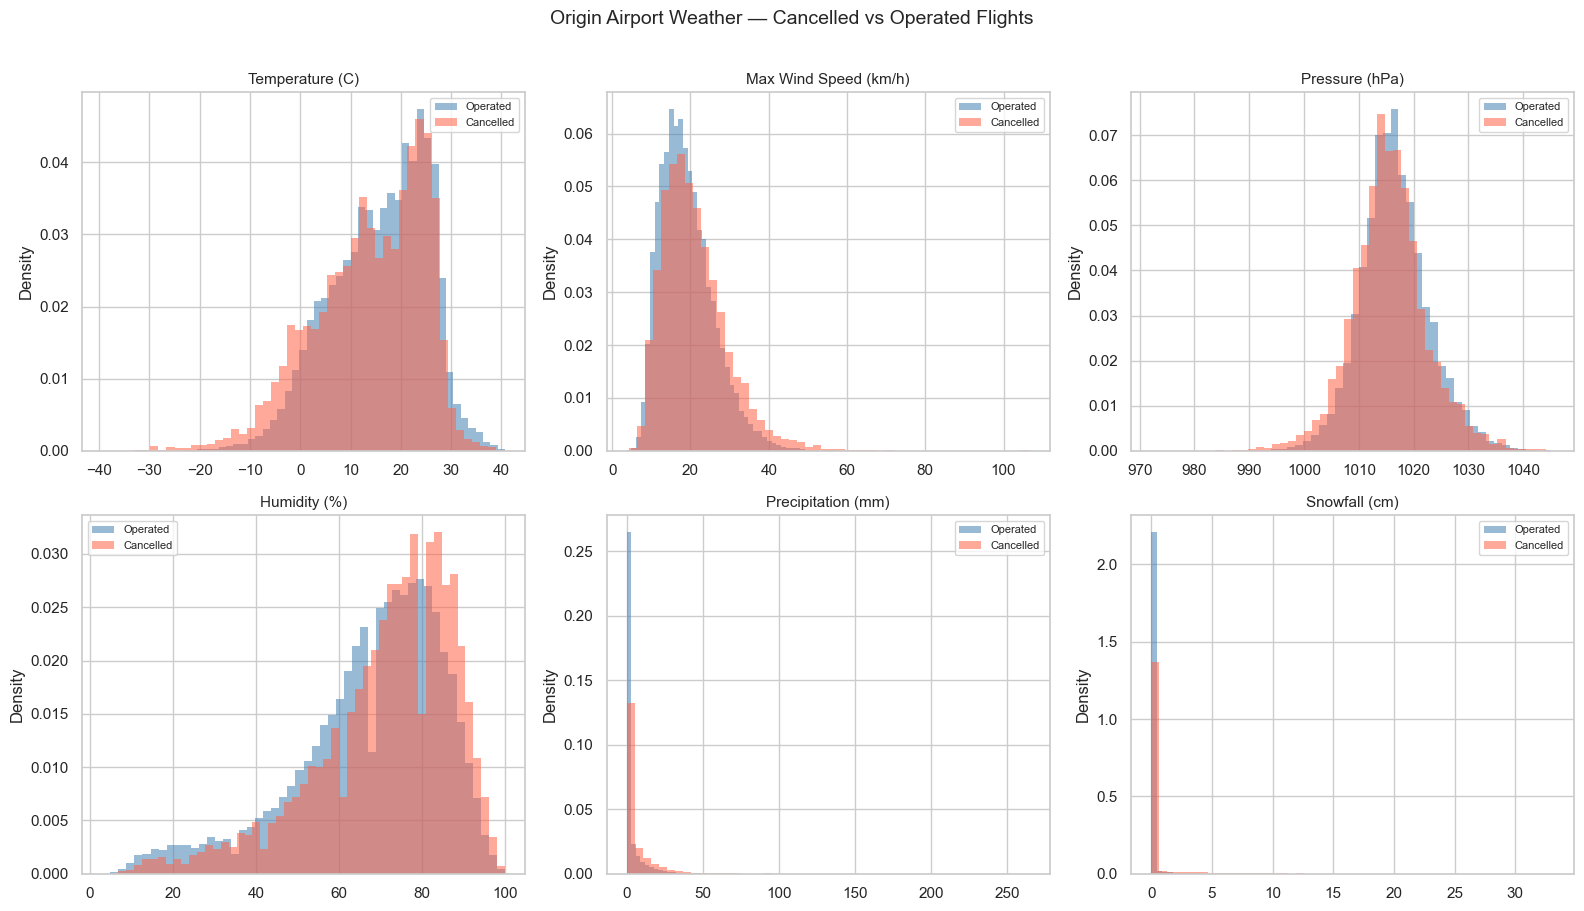

In [61]:
if wx_cols:
    origin_wx = [c for c in wx_cols if c.startswith('origin_')]
    nice_names = {
        'origin_temp_mean_c': 'Temperature (C)',
        'origin_wind_speed_max_kmh': 'Max Wind Speed (km/h)',
        'origin_pressure_msl_hpa': 'Pressure (hPa)',
        'origin_humidity_pct': 'Humidity (%)',
        'origin_precipitation_mm': 'Precipitation (mm)',
        'origin_snowfall_cm': 'Snowfall (cm)',
    }

    n = len(origin_wx)
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for i, col in enumerate(origin_wx):
        ax = axes[i]
        for label, color, name in [(0, 'steelblue', 'Operated'), (1, 'tomato', 'Cancelled')]:
            data = df_raw.loc[df_raw['CANCELLED'] == label, col].dropna()
            if len(data) > 50_000:
                data = data.sample(50_000, random_state=42)
            ax.hist(data, bins=50, alpha=0.55, color=color, label=name, density=True, edgecolor='none')
        ax.set_title(nice_names.get(col, col), fontsize=11)
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    plt.suptitle('Origin Airport Weather — Cancelled vs Operated Flights', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

#### Weather vs cancellation rate (binned)

The histograms above give us a feel for the distributions, but let's also look at cancellation rates within weather bins to see the direct relationship.

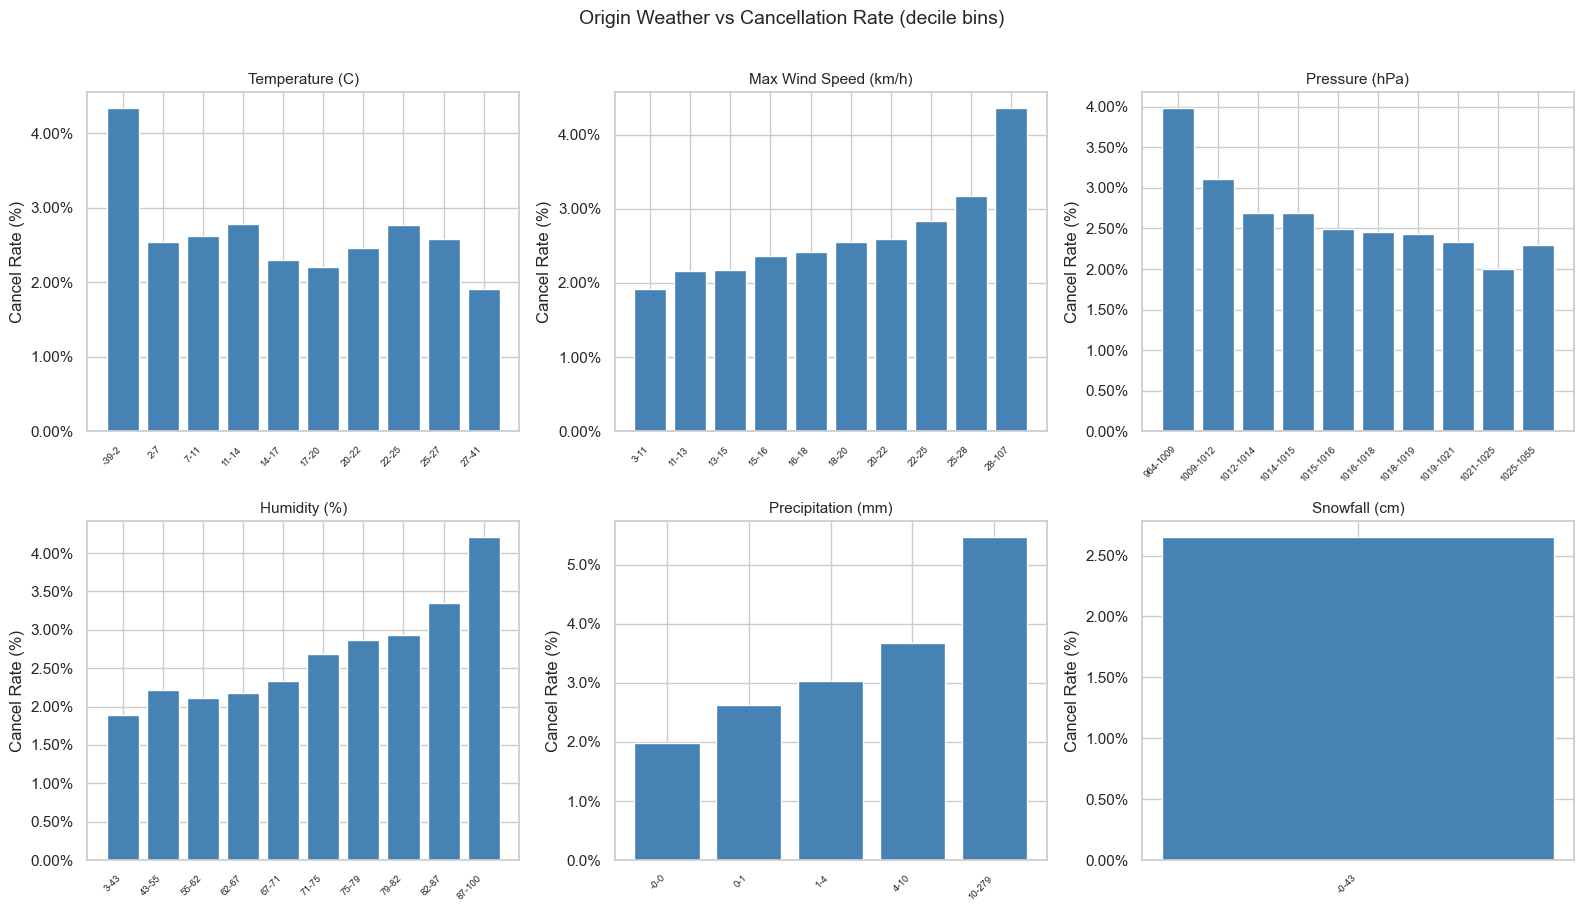

In [62]:
if wx_cols:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for i, col in enumerate(origin_wx):
        ax = axes[i]
        temp = df_raw[[col, 'CANCELLED']].dropna()
        temp['bin'] = pd.qcut(temp[col], q=10, duplicates='drop')
        grouped = temp.groupby('bin', observed=True)['CANCELLED'].agg(['mean', 'count'])
        bars = ax.bar(range(len(grouped)), grouped['mean'] * 100,
                      color='steelblue', edgecolor='white')
        ax.set_xticks(range(len(grouped)))
        labels = [f'{iv.left:.0f}-{iv.right:.0f}' if hasattr(iv, 'left') else str(iv)
                  for iv in grouped.index]
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.set_ylabel('Cancel Rate (%)')
        ax.set_title(nice_names.get(col, col), fontsize=11)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    plt.suptitle('Origin Weather vs Cancellation Rate (decile bins)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

#### Snowfall deep dive

Snowfall is likely the most direct weather driver of cancellations. Let's look at how cancellation rates change as snowfall increases, and whether the pattern holds for both origin and destination airports.

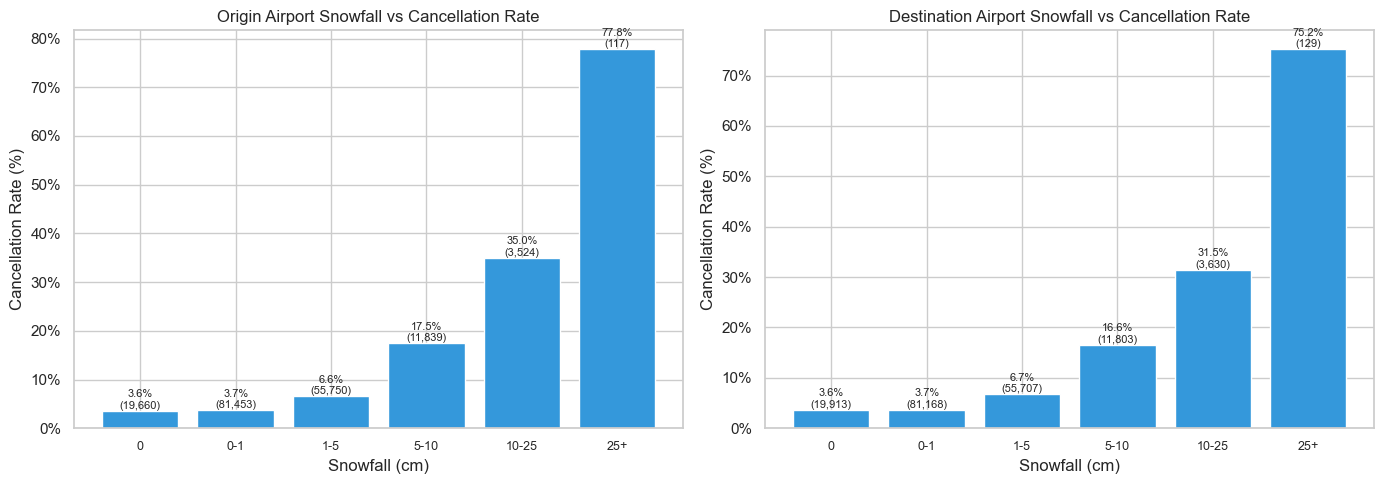

In [63]:
if wx_cols and 'origin_snowfall_cm' in df_raw.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, prefix, label in [(axes[0], 'origin', 'Origin'), (axes[1], 'dest', 'Destination')]:
        col = f'{prefix}_snowfall_cm'
        if col not in df_raw.columns:
            ax.set_visible(False)
            continue
        temp = df_raw[[col, 'CANCELLED']].dropna()
        bins = [0, 0.1, 1, 5, 10, 25, 100]
        bin_labels = ['0', '0-1', '1-5', '5-10', '10-25', '25+']
        temp['snow_bin'] = pd.cut(temp[col], bins=bins, labels=bin_labels, right=True)
        grouped = temp.groupby('snow_bin', observed=True)['CANCELLED'].agg(['mean', 'count'])

        bars = ax.bar(range(len(grouped)), grouped['mean'] * 100,
                      color='#3498db', edgecolor='white')
        ax.set_xticks(range(len(grouped)))
        ax.set_xticklabels(grouped.index, fontsize=9)
        ax.set_xlabel('Snowfall (cm)')
        ax.set_ylabel('Cancellation Rate (%)')
        ax.set_title(f'{label} Airport Snowfall vs Cancellation Rate')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        for j, bar in enumerate(bars):
            ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                    f'{bar.get_height():.1f}%\n({grouped.iloc[j]["count"]:,.0f})',
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

#### Weather correlation with cancellation

Finally, let's see how each weather feature correlates with the cancellation target. This tells us which weather variables the model is most likely to find useful.

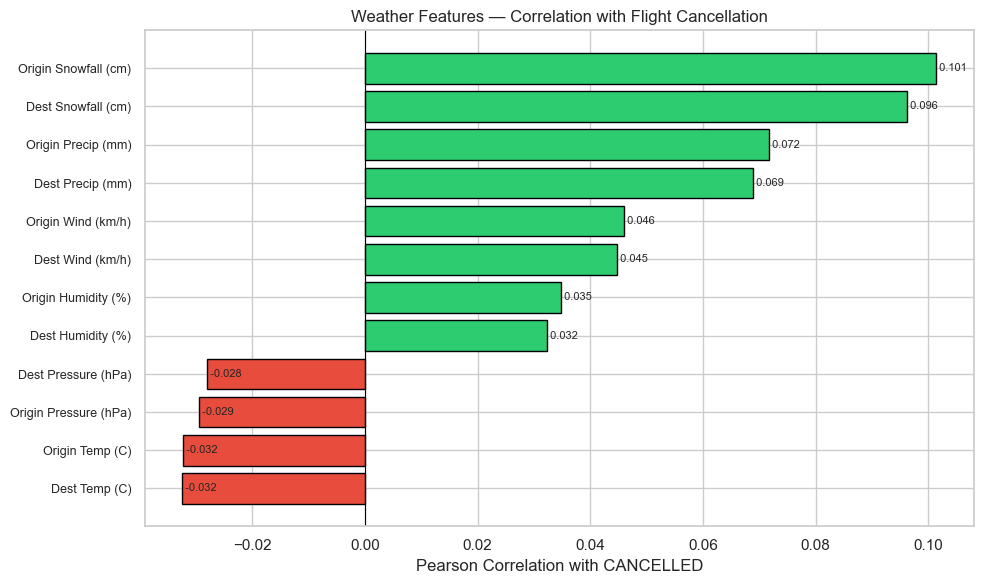

In [64]:
if wx_cols:
    wx_corr = df_raw[wx_cols + ['CANCELLED']].corr()['CANCELLED'].drop('CANCELLED').sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in wx_corr.values]
    ax.barh(range(len(wx_corr)), wx_corr.values, color=colors, edgecolor='black')
    ax.set_yticks(range(len(wx_corr)))
    nice_wx = {
        'origin_temp_mean_c': 'Origin Temp (C)',
        'origin_wind_speed_max_kmh': 'Origin Wind (km/h)',
        'origin_pressure_msl_hpa': 'Origin Pressure (hPa)',
        'origin_humidity_pct': 'Origin Humidity (%)',
        'origin_precipitation_mm': 'Origin Precip (mm)',
        'origin_snowfall_cm': 'Origin Snowfall (cm)',
        'dest_temp_mean_c': 'Dest Temp (C)',
        'dest_wind_speed_max_kmh': 'Dest Wind (km/h)',
        'dest_pressure_msl_hpa': 'Dest Pressure (hPa)',
        'dest_humidity_pct': 'Dest Humidity (%)',
        'dest_precipitation_mm': 'Dest Precip (mm)',
        'dest_snowfall_cm': 'Dest Snowfall (cm)',
    }
    ax.set_yticklabels([nice_wx.get(c, c) for c in wx_corr.index], fontsize=9)
    ax.set_xlabel('Pearson Correlation with CANCELLED')
    ax.set_title('Weather Features — Correlation with Flight Cancellation')
    ax.axvline(0, color='black', linewidth=0.8)
    for i, v in enumerate(wx_corr.values):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

### 1.8 Cancellation Code Analysis

`CANCELLATION_CODE` is only filled in *after* a flight gets cancelled, so it's a textbook case of target leakage — we can't use it as a feature. But it's still useful for understanding *why* flights are cancelled, which helps us set realistic expectations for how well any model can do.

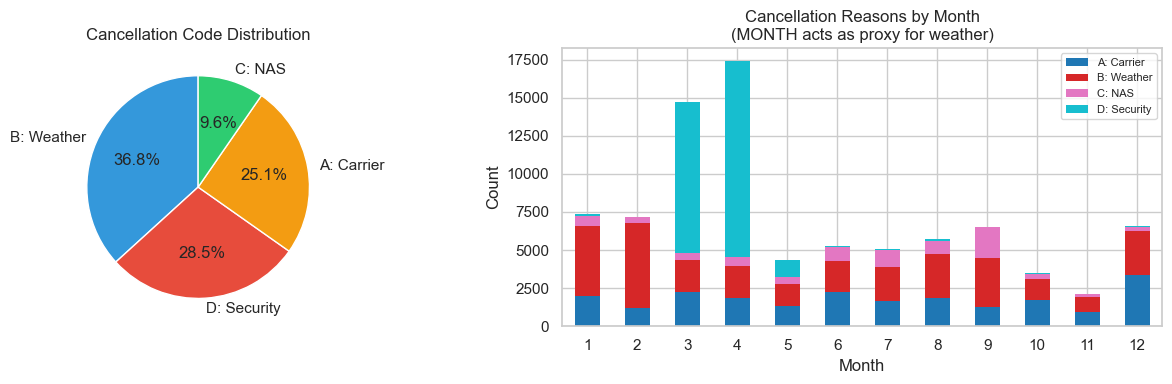

CANCELLATION_CODE = target leakage. Excluded from all model features.


In [65]:
cancelled = df_raw[df_raw['CANCELLED'] == 1].copy()
code_map = {'A': 'A: Carrier', 'B': 'B: Weather', 'C': 'C: NAS', 'D': 'D: Security'}
cancelled['Code'] = cancelled['CANCELLATION_CODE'].astype(str).map(code_map).fillna('Unknown')
code_counts = cancelled['Code'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].pie(
    code_counts.values, labels=code_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#95a5a6'],
    wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('Cancellation Code Distribution')

monthly_codes = (
    cancelled.groupby(['MONTH', 'Code'])
    .size().unstack(fill_value=0)
)
monthly_codes.plot(kind='bar', stacked=True, ax=axes[1],
                   colormap='tab10', edgecolor='none')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].set_title('Cancellation Reasons by Month\n(MONTH acts as proxy for weather)')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('CANCELLATION_CODE = target leakage. Excluded from all model features.')

### 1.9 Correlation Heatmap

The linear correlations with `CANCELLED` are quite weak, which suggests non-linear models (trees, XGBoost) are a better fit than plain logistic regression. Also note that `DISTANCE` and `CRS_ELAPSED_TIME` are highly correlated — multicollinearity could be an issue for linear models.

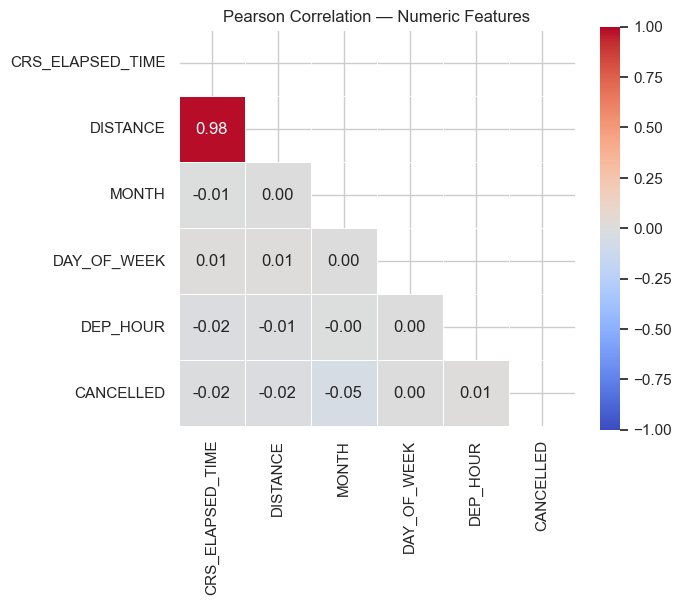

Weak correlations with CANCELLED confirm non-linear relationships.
DISTANCE / CRS_ELAPSED_TIME are highly correlated — watch for multicollinearity in LogReg.


In [66]:
num_cols = ['CRS_ELAPSED_TIME', 'DISTANCE', 'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'CANCELLED']
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Pearson Correlation — Numeric Features')
plt.tight_layout()
plt.show()

print('Weak correlations with CANCELLED confirm non-linear relationships.')
print('DISTANCE / CRS_ELAPSED_TIME are highly correlated — watch for multicollinearity in LogReg.')